###### Patricia Clarji 202500382 | Marie-Lie kadado 202402112

# Diabetes Readmission Prediction

## Objectives
- **Multiclass Classification:** Predict the patient's readmission category (`readmitted`)
- **Regression:** Predict time spent in hospital (`time_in_hospital`)

Dataset:
Diabetes 130-US Hospitals Dataset

### Project Description

Hospital readmissions are costly and may indicate complications in patient care.
The goal of this project is to analyze hospital records of diabetic patients and build machine learning models for:

- **Multiclass classification:** predict the patient's readmission category (`NO`, `>30`, `<30`)
- **Regression:** predict the patient's length of stay in the hospital (`time_in_hospital`)

The dataset contains hospital records of diabetic patients from 1999–2008 across 130 US hospitals.

### Step 1- Import Libraries and Models

In [1]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.patches import Rectangle

### Step 2- Load DataSet

In [2]:
#Config:
DATA_PATH = "../data/diabetes.csv"
CLASSIFICATION_TARGET = "readmitted"
REGRESSION_TARGET = "time_in_hospital"
RANDOM_STATE = 42
TARGET= 'readmitted'

In [3]:
# Load dataset
df = pd.read_csv(DATA_PATH, na_values='?')

columns = df.columns

warnings.filterwarnings("ignore", category=FutureWarning)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_57928\1962435258.py:2: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH, na_values='?')


In [4]:
# Split Categorical and Numerical Columns
categorical_cols = [
    'race', 'gender', 'age', 'weight',
    'payer_code', 'medical_specialty',
    'diag_1', 'diag_2', 'diag_3',
    'max_glu_serum', 'A1Cresult',
    'metformin', 'repaglinide', 'nateglinide',
    'chlorpropamide', 'glimepiride', 'acetohexamide',
    'glipizide', 'glyburide', 'tolbutamide',
    'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin',
    'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone', 'change', 'diabetesMed',
    'readmitted'
]

numerical_cols = [
    'encounter_id', 'patient_nbr',
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]

### Step 3- Dataset Overview

#### 3.1 Head (5 rows)

In [5]:
print("Dataset preview:")
display(df.head(10))


Dataset preview:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),NaN,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),NaN,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),NaN,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),NaN,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),NaN,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


#### 3.2 Info

In [6]:
print("\nDataset info:")
df.info()


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications 

#### 3.3 Missing values

In [7]:
print("\nMissing values per column:")
display(df.isnull().sum().sort_values(ascending=False))


Missing values per column:


weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
patient_nbr                     0
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
encounter_id                    0
admission_type_id               0
discharge_disposition_id        0
gender                          0
age                             0
number_inpatient                0
number_emergency                0
number_outpatient               0
num_medications                 0
num_procedures                  0
number_diagnoses                0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

#### 3.4 Numerical cols

In [8]:
print("\nNumerical summary:")
display(df[numerical_cols].describe().round(2))


Numerical summary:


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,1.652016e+08,5.433040e+07,2.02,3.72,5.75,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,1.026403e+08,3.869636e+07,1.45,5.28,4.06,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.252200e+04,1.350000e+02,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,8.496119e+07,2.341322e+07,1.00,1.00,1.00,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,1.523890e+08,4.550514e+07,1.00,1.00,7.00,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,2.302709e+08,8.754595e+07,3.00,4.00,7.00,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,4.438672e+08,1.895026e+08,8.00,28.00,25.00,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


#### 3.5 Categorical cols

In [9]:
print("\nCategorical summary:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))
    print("-" * 40)


Categorical summary:

Column: race
race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64
----------------------------------------

Column: gender
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64
----------------------------------------

Column: age
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64
----------------------------------------

Column: weight
weight
NaN          98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64
----------------------------------------

Column: payer_code
payer_code
Na

#### 3.6 Other

In [10]:
print("\nShape of dataset:", df.shape)
print("\nNumber of numeric columns:", len(numerical_cols))
print("\nNumber of categorical columns:", len(categorical_cols))
print("\nClassification target:", CLASSIFICATION_TARGET)
print("\nRegression target:", REGRESSION_TARGET)


Shape of dataset: (101766, 50)

Number of numeric columns: 13

Number of categorical columns: 37

Classification target: readmitted

Regression target: time_in_hospital


### Step 4- EDA Exploratory Data Analysis
In this step, we explore the dataset using visualizations to identify patterns, trends, and relationships between variables. This helps in understanding the data before applying preprocessing and machine learning models.

#### 4.0 Visualization SetUp

In [11]:
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

readmit_order = ['NO', '>30', '<30']
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
            '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

num_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_medications',
    'number_outpatient',
    'number_inpatient'
]

utilization_cols = [
    'number_outpatient',
    'number_emergency',
    'number_inpatient'
]

corr_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]

#### 4.1 Target Variable Analysis
In this section, we analyze the target variables of the project: readmitted for the classification task and time_in_hospital for the regression task. This helps us understand class balance, distribution shape, and potential modeling challenges.

##### A- Readmission Distribution

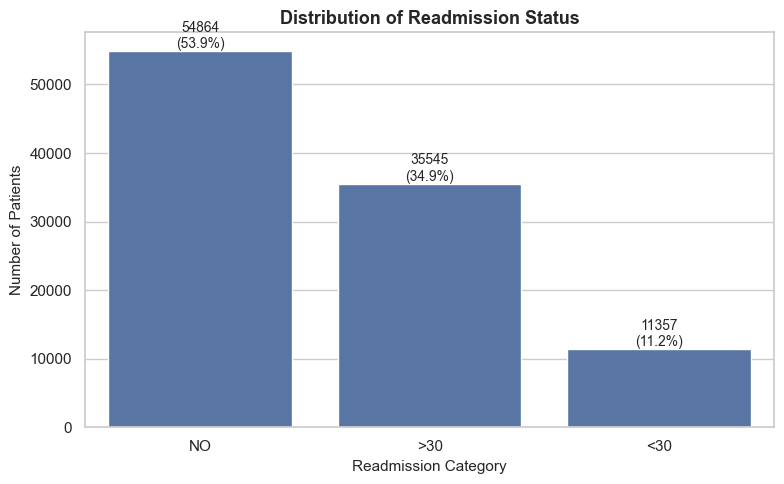

In [12]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df, x='readmitted', order=readmit_order)

total = len(df)
for p in ax.patches:
    if isinstance(p, Rectangle):
        count = int(p.get_height())
        pct = 100 * count / total
        ax.annotate(
            f"{count}\n({pct:.1f}%)",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title("Distribution of Readmission Status")
plt.xlabel("Readmission Category")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

#### Interpretation
Most patients were not readmitted, while the <30 class is the smallest. This shows class imbalance, which matters for the classification task.

#### B- time_in_hospital distribution
Next, we analyze the regression target time_in_hospital to understand its distribution, central tendency, and potential skewness or outliers.

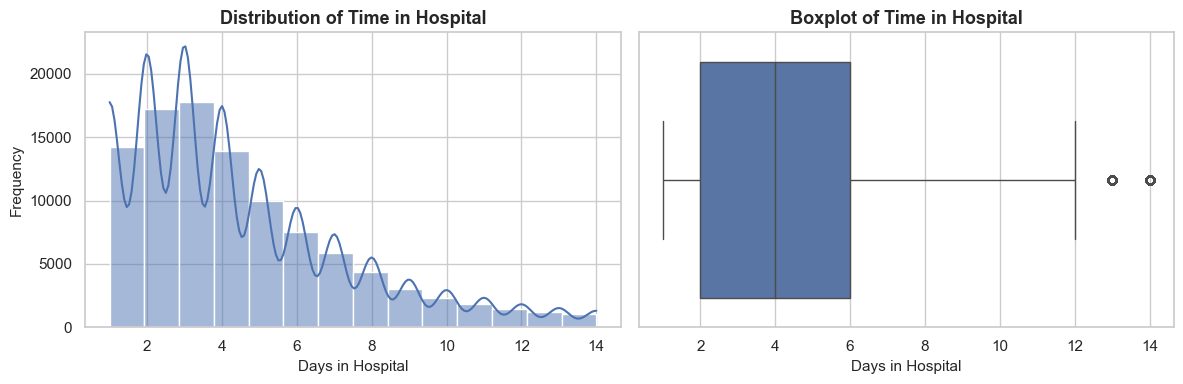

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x='time_in_hospital', bins=14, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Time in Hospital")
axes[0].set_xlabel("Days in Hospital")
axes[0].set_ylabel("Frequency")

sns.boxplot(data=df, x='time_in_hospital', ax=axes[1])
axes[1].set_title("Boxplot of Time in Hospital")
axes[1].set_xlabel("Days in Hospital")

plt.tight_layout()
plt.show()

##### Interpretation

Most hospital stays are short, concentrated around a few days(peek btw 3-4 days), while a smaller number of cases have much longer stays. The boxplot also shows some outliers.

#### 4.2 Univariate Analysis

##### A- Numerical Features Distributions

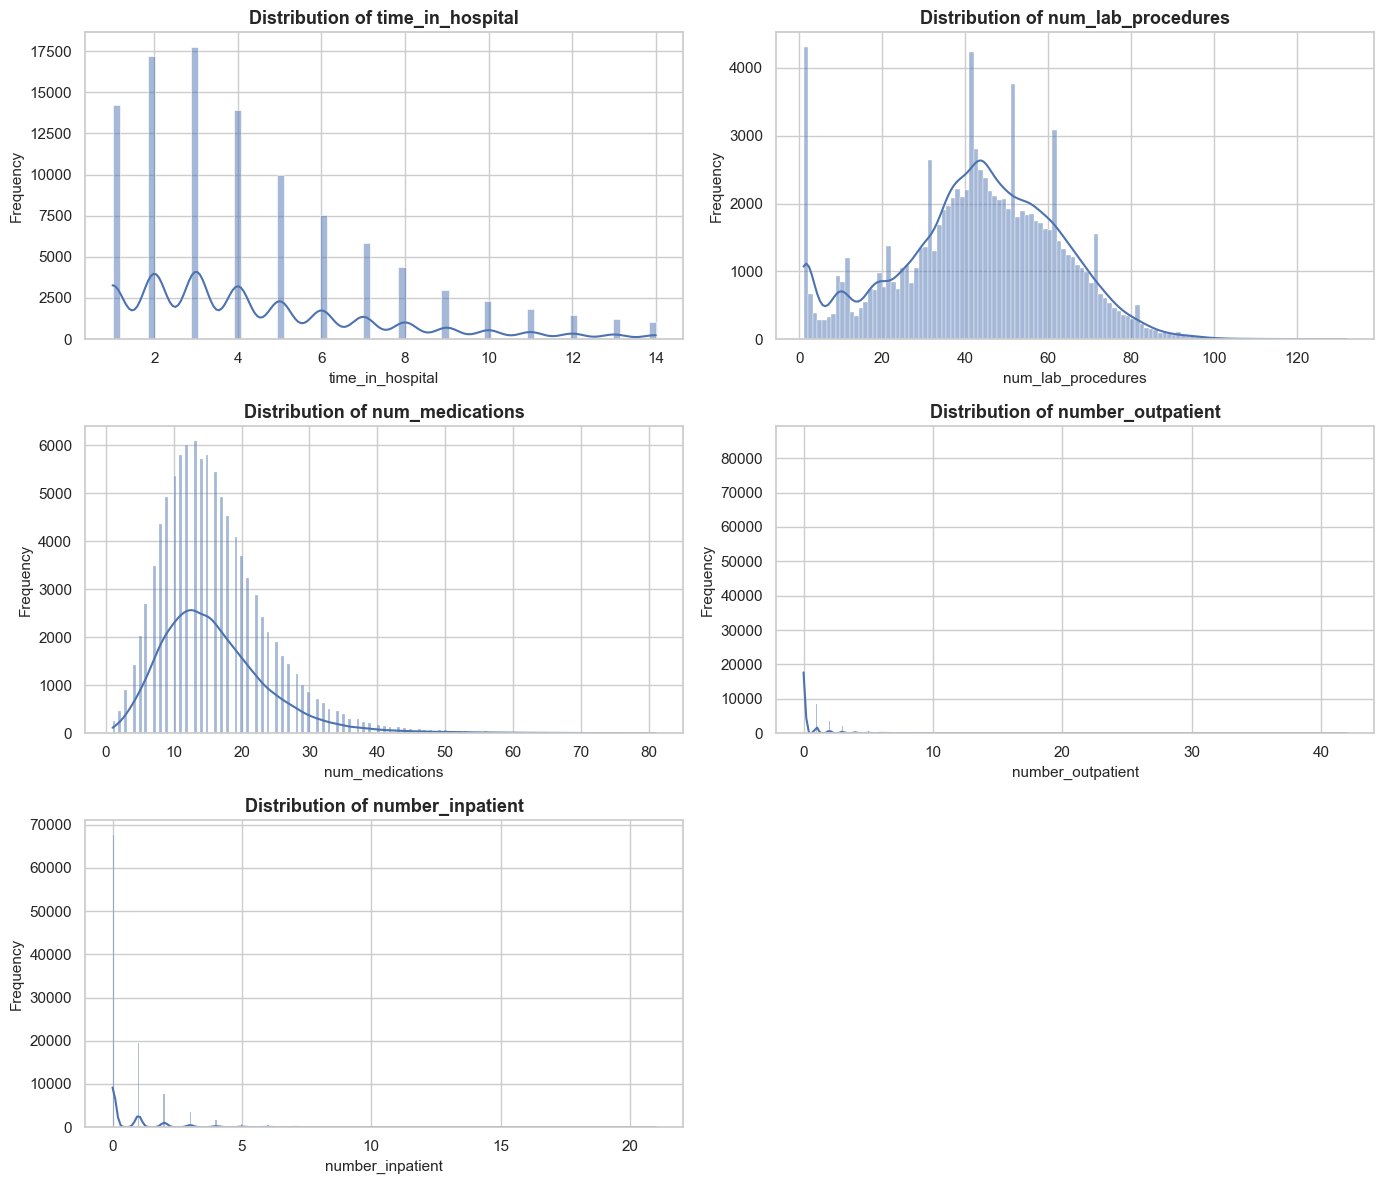

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

##### B- Numerical Feature Outlier

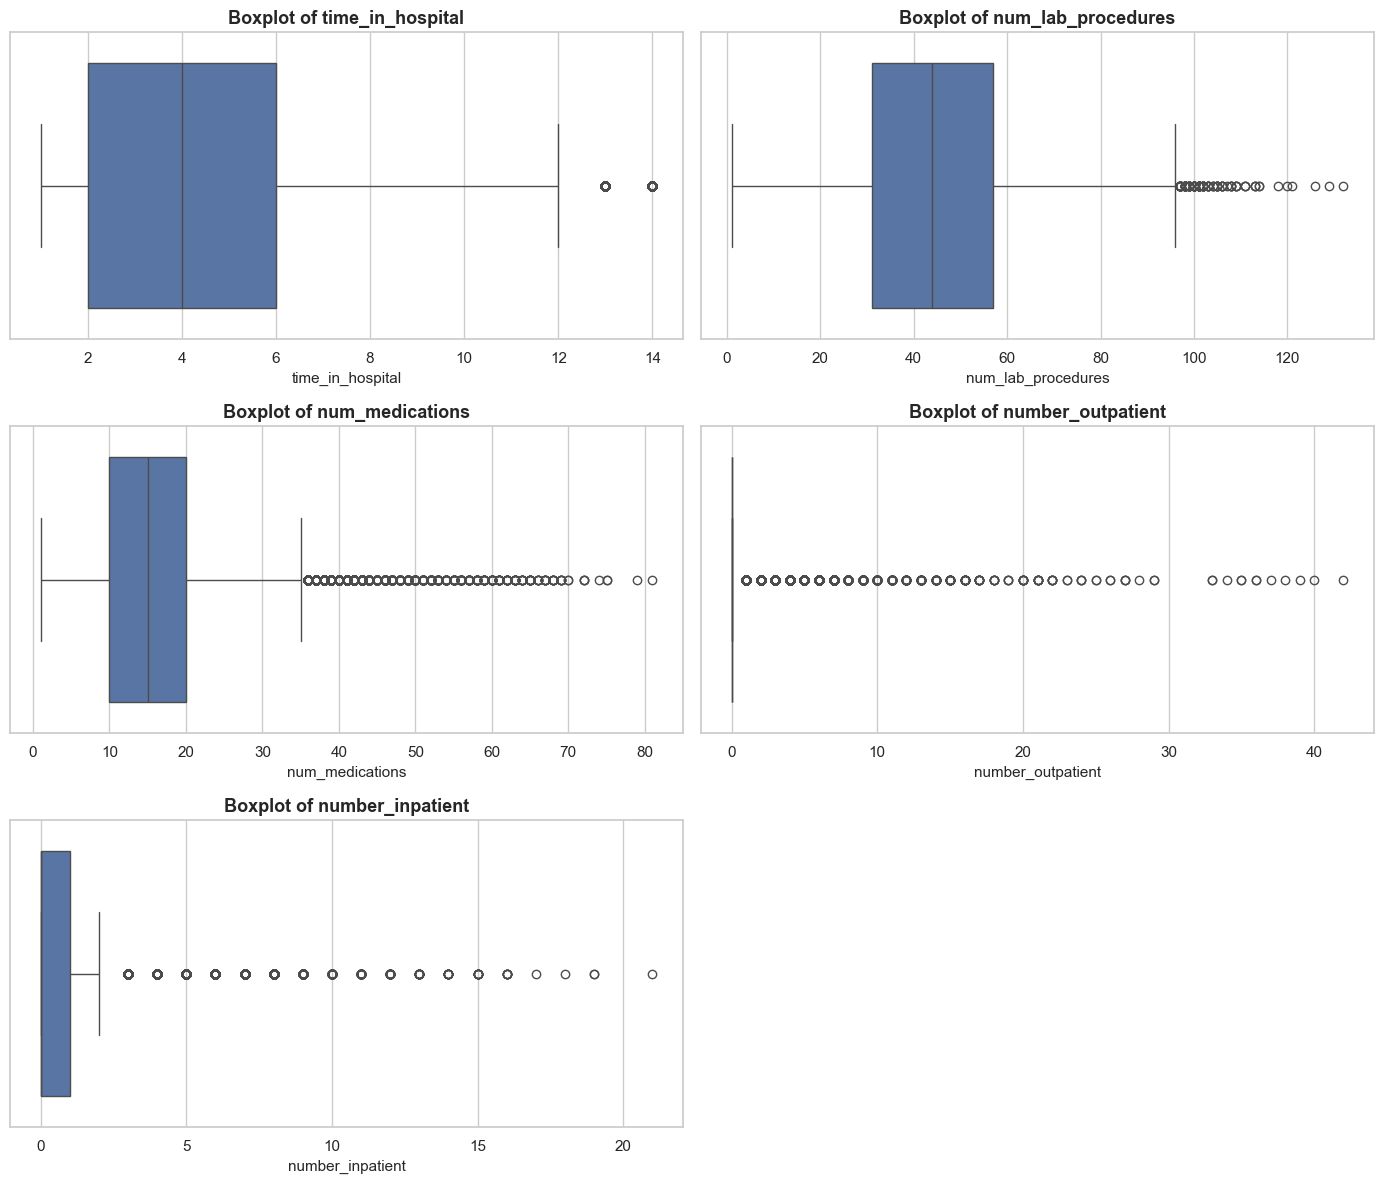

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

##### C- Categorical Features Distribution

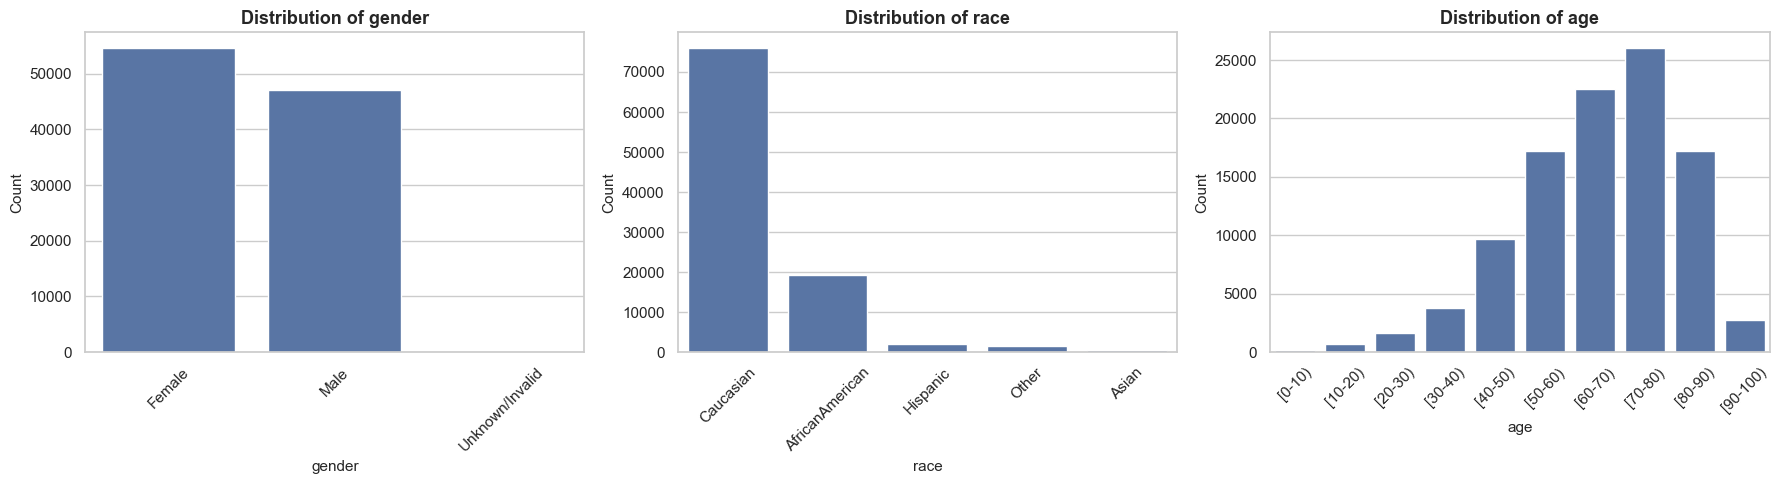

In [16]:
cat_cols = ['gender', 'race', 'age']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = age_order if col == 'age' else df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Interpretation
Patients who are readmitted tend to have longer hospital stays, more medications, and more prior inpatient visits. These variables strongly indicate patient complexity and are likely to be important predictors.

#### 4.3 Bivariate Analysis: Features vs Readmission

##### A- Demographic Features

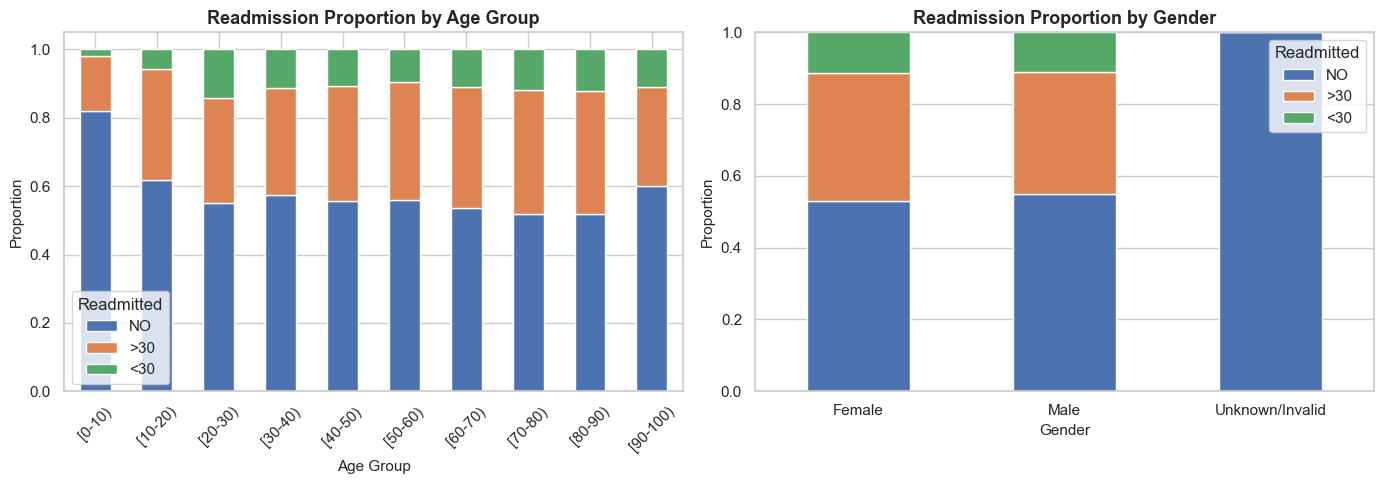

In [17]:
age_readmit = pd.crosstab(df['age'], df['readmitted'], normalize='index').reindex(age_order)
gender_order = df['gender'].value_counts().index
gender_readmit = pd.crosstab(df['gender'], df['readmitted'], normalize='index').reindex(gender_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_readmit[readmit_order].plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title("Readmission Proportion by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Proportion")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Readmitted')

gender_readmit[readmit_order].plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title("Readmission Proportion by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Proportion")
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Readmitted')

plt.tight_layout()
plt.show()

#### Interpretation
Older age groups show higher readmission proportions, suggesting age may be an important predictor. Gender differences are minimal, indicating that gender alone may not strongly influence readmission.

##### B- Clinical Features

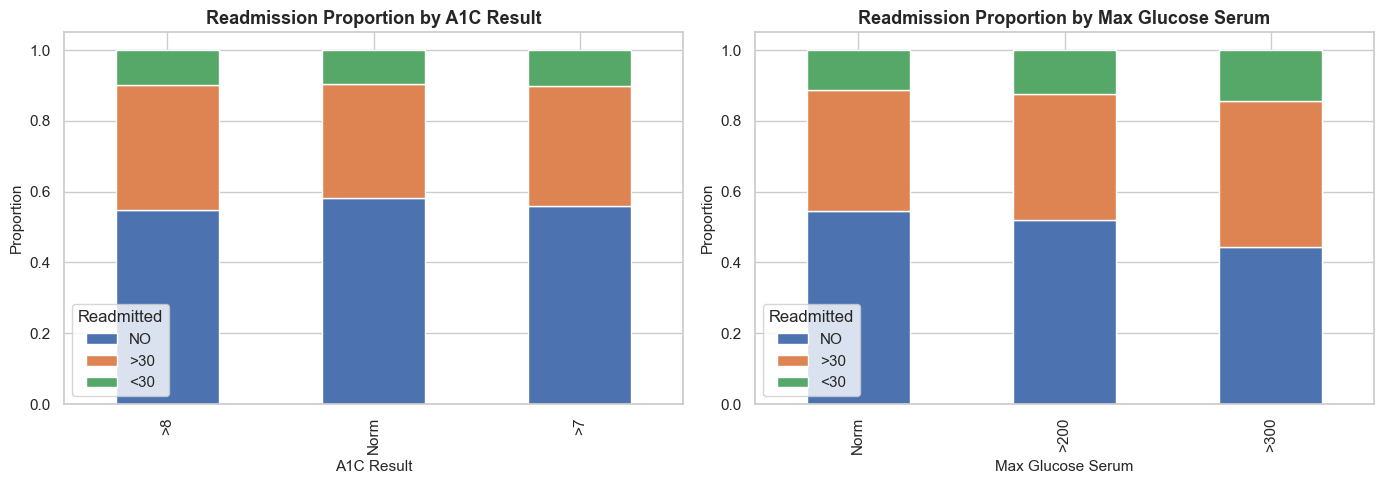

In [18]:
a1c_order = df['A1Cresult'].value_counts().index
a1c_readmit = pd.crosstab(df['A1Cresult'], df['readmitted'], normalize='index').reindex(a1c_order)

glu_order = df['max_glu_serum'].value_counts().index
glu_readmit = pd.crosstab(df['max_glu_serum'], df['readmitted'], normalize='index').reindex(glu_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

a1c_readmit[readmit_order].plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title("Readmission Proportion by A1C Result")
axes[0].set_xlabel("A1C Result")
axes[0].set_ylabel("Proportion")
axes[0].legend(title='Readmitted')

glu_readmit[readmit_order].plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title("Readmission Proportion by Max Glucose Serum")
axes[1].set_xlabel("Max Glucose Serum")
axes[1].set_ylabel("Proportion")
axes[1].legend(title='Readmitted')

plt.tight_layout()
plt.show()

#### Interpretation
Patients with abnormal A1C and glucose results tend to have higher readmission proportions. This suggests that poor glycemic control is associated with increased readmission risk.

#### C- Hospital Utilization Features

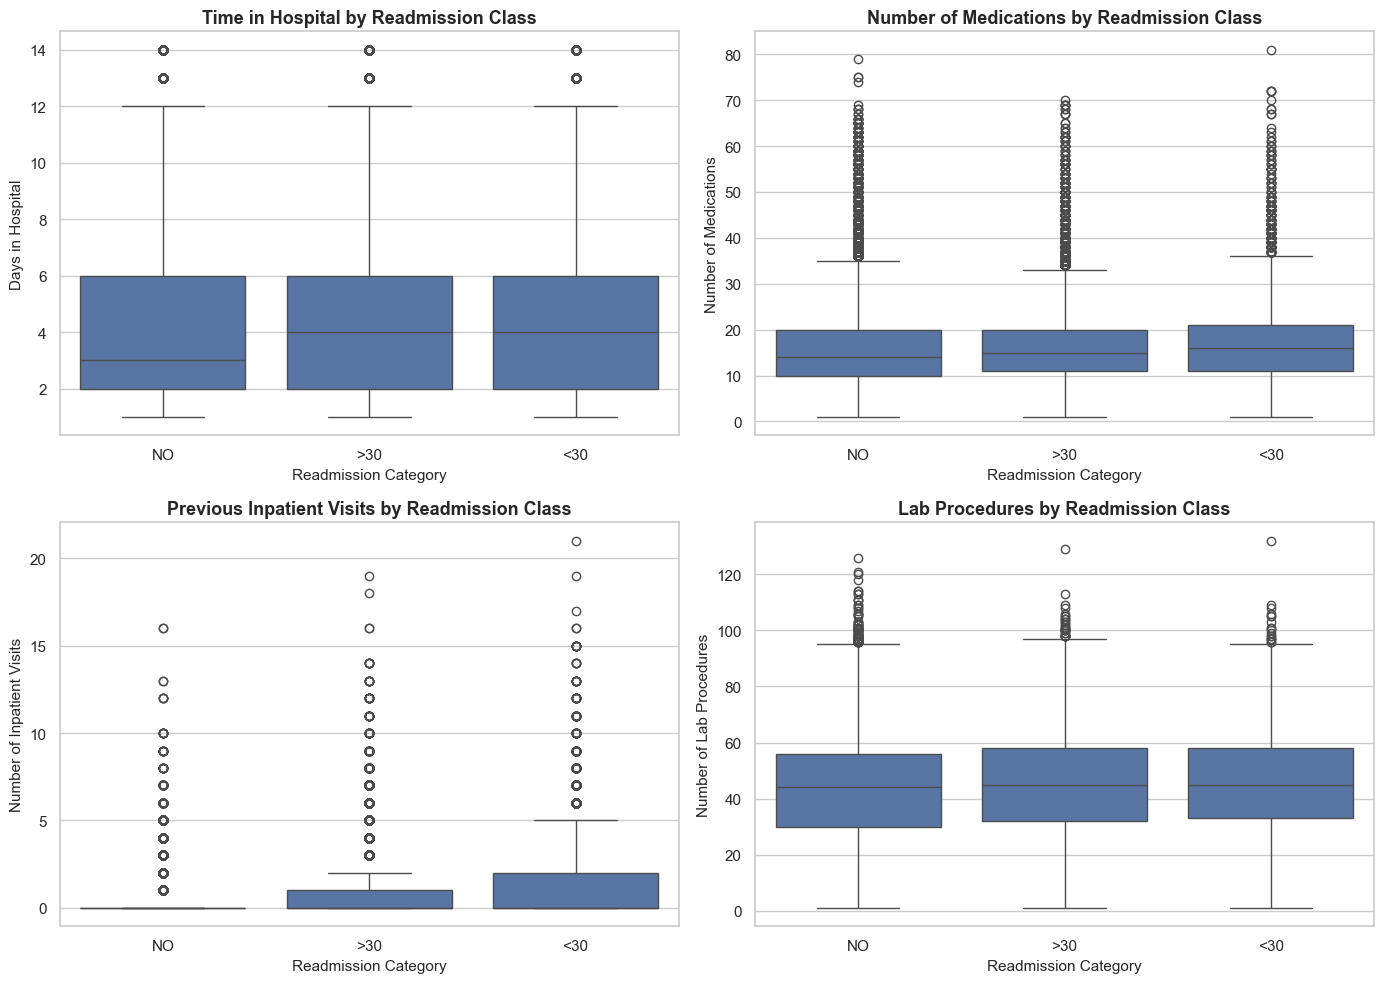

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

sns.boxplot(data=df, x='readmitted', y='time_in_hospital', order=readmit_order, ax=axes[0])
axes[0].set_title("Time in Hospital by Readmission Class")
axes[0].set_xlabel("Readmission Category")
axes[0].set_ylabel("Days in Hospital")

sns.boxplot(data=df, x='readmitted', y='num_medications', order=readmit_order, ax=axes[1])
axes[1].set_title("Number of Medications by Readmission Class")
axes[1].set_xlabel("Readmission Category")
axes[1].set_ylabel("Number of Medications")

sns.boxplot(data=df, x='readmitted', y='number_inpatient', order=readmit_order, ax=axes[2])
axes[2].set_title("Previous Inpatient Visits by Readmission Class")
axes[2].set_xlabel("Readmission Category")
axes[2].set_ylabel("Number of Inpatient Visits")

sns.boxplot(data=df, x='readmitted', y='num_lab_procedures', order=readmit_order, ax=axes[3])
axes[3].set_title("Lab Procedures by Readmission Class")
axes[3].set_xlabel("Readmission Category")
axes[3].set_ylabel("Number of Lab Procedures")

plt.tight_layout()
plt.show()

#### Interpretation
Patients who are readmitted tend to have longer hospital stays, use more medications, and have more previous inpatient visits. These patterns suggest that hospital utilization and clinical complexity are strongly related to readmission risk.

#### 4.4. Missingness Overview

##### A- Missing percentage by feature

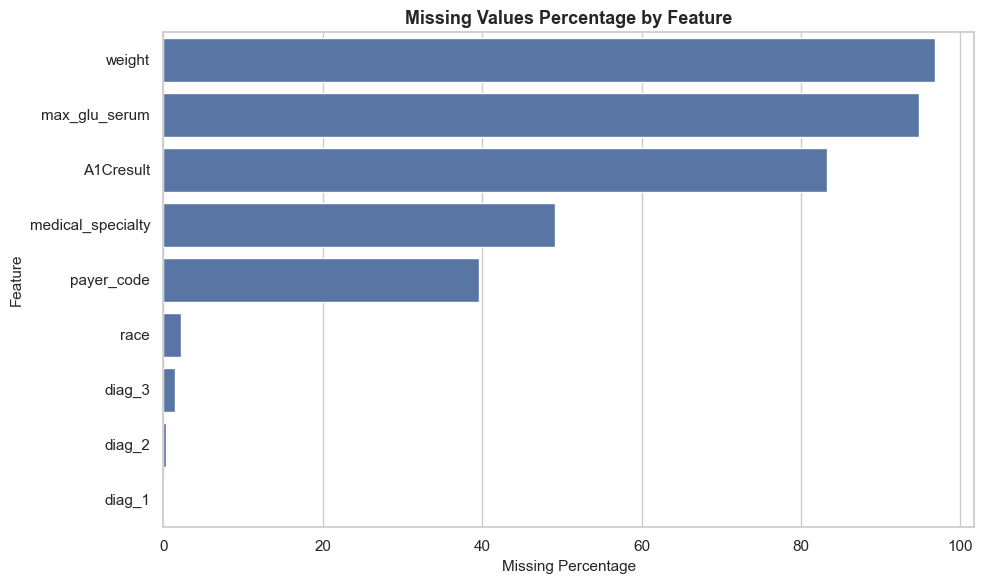

In [20]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_pct.values, y=missing_pct.index)
plt.title("Missing Values Percentage by Feature")
plt.xlabel("Missing Percentage")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

##### B- Missingness heatmap for columns with missing values

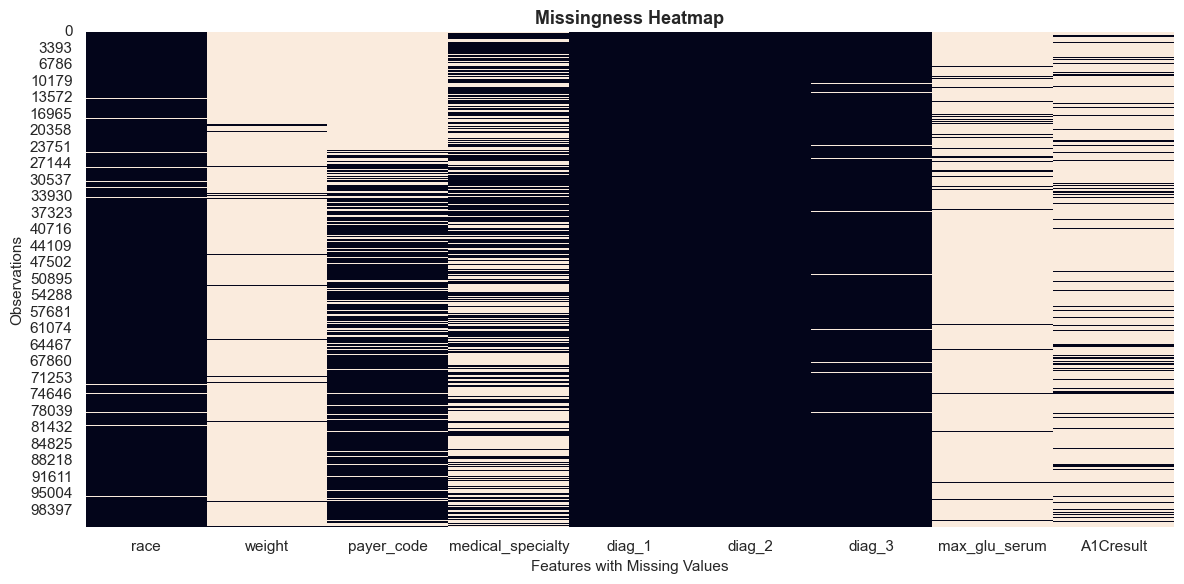

In [21]:
missing_cols = df.columns[df.isnull().any()].tolist()

plt.figure(figsize=(12, 6))
sns.heatmap(df[missing_cols].isnull(), cbar=False)
plt.title("Missingness Heatmap")
plt.xlabel("Features with Missing Values")
plt.ylabel("Observations")
plt.tight_layout()
plt.show()

#### 4.5 Correlation and Numerical Relationships

##### A- Correlation heatmap

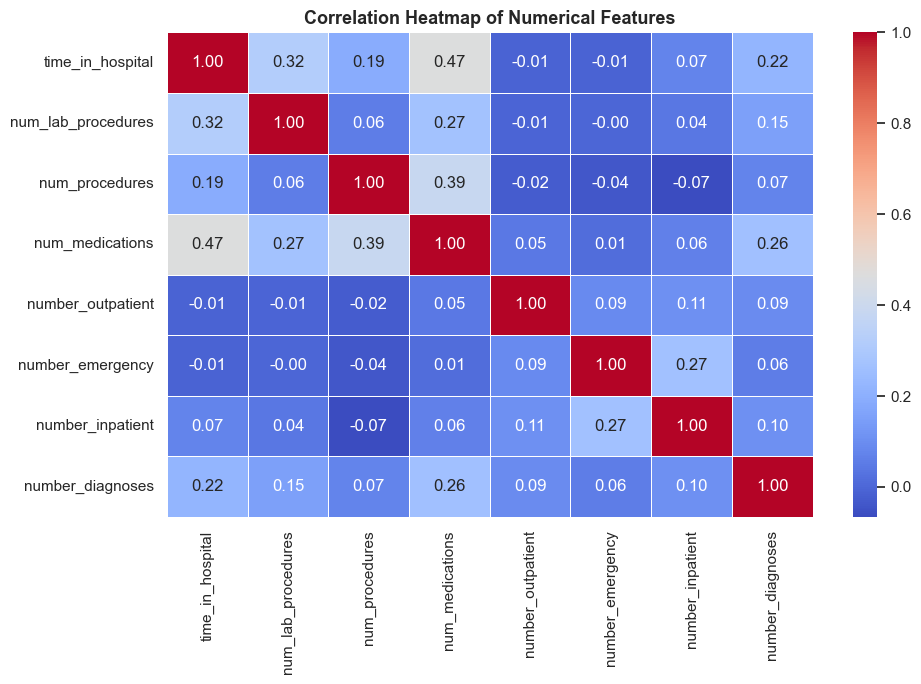

In [22]:
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

#### Interpretation

The scatterplots show moderate positive relationships between several numerical features. In particular, patients with more diagnoses and lab procedures tend to receive more medications. While these relationships are not extremely strong, they indicate that combinations of these variables may be useful for predicting readmission. No severe linear relationships are observed, suggesting that multicollinearity may not be a major issue.

##### B- Selected numerical relationship plots

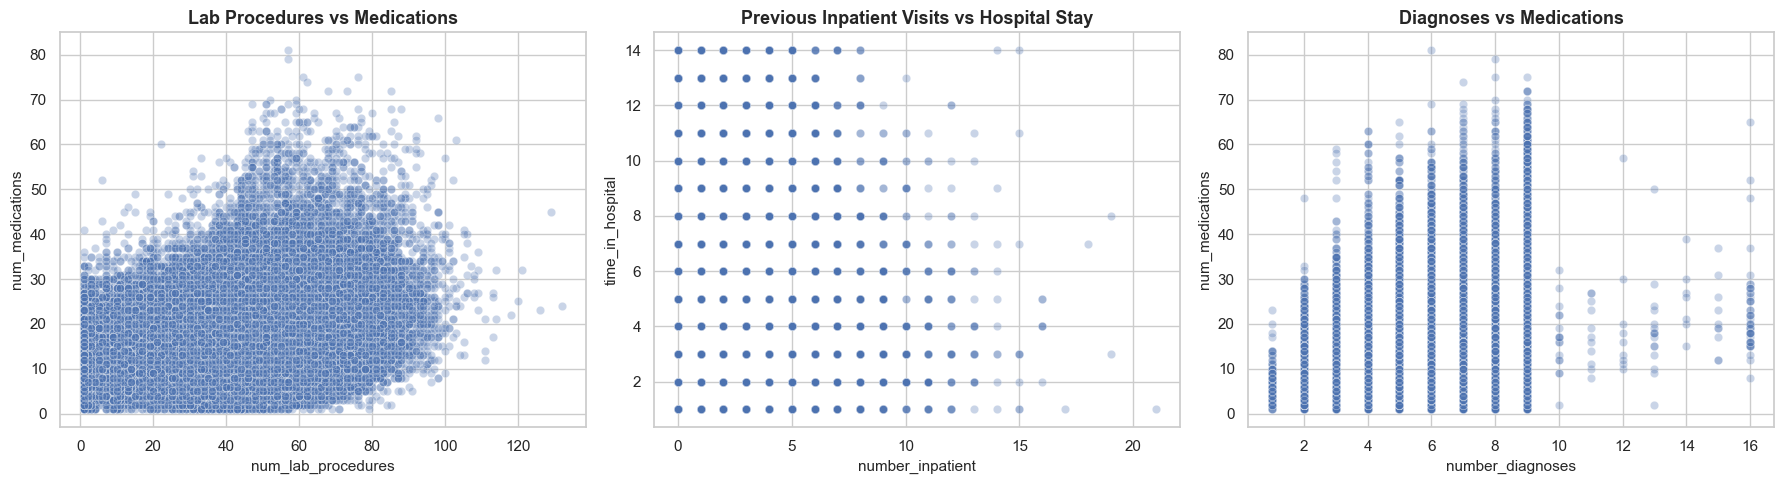

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='num_lab_procedures', y='num_medications', alpha=0.3, ax=axes[0])
axes[0].set_title("Lab Procedures vs Medications")

sns.scatterplot(data=df, x='number_inpatient', y='time_in_hospital', alpha=0.3, ax=axes[1])
axes[1].set_title("Previous Inpatient Visits vs Hospital Stay")

sns.scatterplot(data=df, x='number_diagnoses', y='num_medications', alpha=0.3, ax=axes[2])
axes[2].set_title("Diagnoses vs Medications")

plt.tight_layout()
plt.show()

#### Interpretation

The scatterplots show moderate positive relationships between several numerical features. In particular, patients with more diagnoses and lab procedures tend to receive more medications. While these relationships are not extremely strong, they indicate that combinations of these variables may be useful for predicting readmission. No severe linear relationships are observed, suggesting that multicollinearity may not be a major issue.

#### 4.6 Additional Categorical Analysis

##### Readmission rate by top race categories

<Figure size 800x500 with 0 Axes>

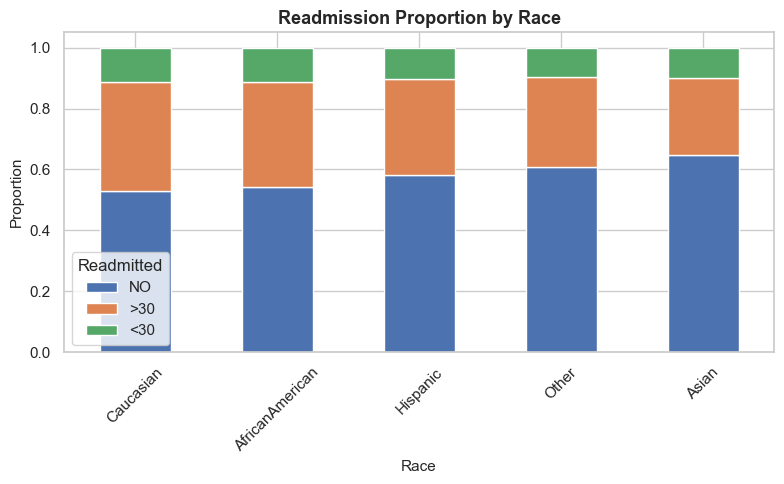

In [24]:
top_race = df['race'].value_counts().index
race_readmit = pd.crosstab(df['race'], df['readmitted'], normalize='index').reindex(top_race)

plt.figure(figsize=(8, 5))
race_readmit[readmit_order].plot(kind='bar', stacked=True)
plt.title("Readmission Proportion by Race")
plt.xlabel("Race")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title='Readmitted')
plt.tight_layout()
plt.show()

##### Readmission rate by admission type

<Figure size 800x500 with 0 Axes>

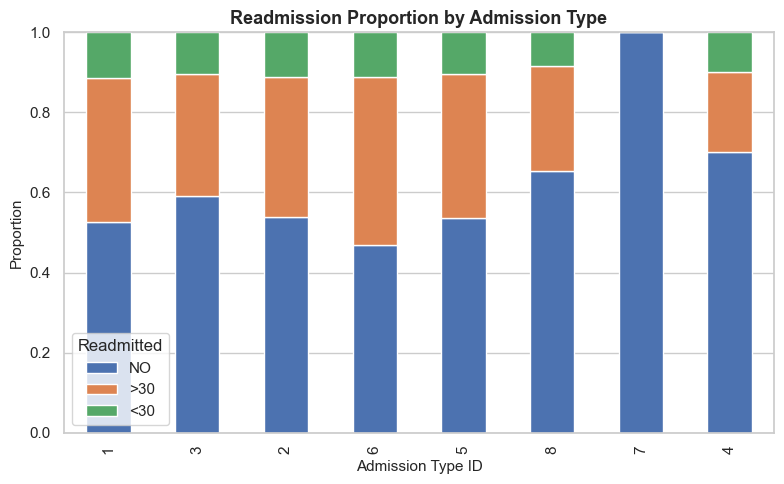

In [25]:
admission_order = df['admission_type_id'].value_counts().index
admission_readmit = pd.crosstab(df['admission_type_id'], df['readmitted'], normalize='index').reindex(admission_order)

plt.figure(figsize=(8, 5))
admission_readmit[readmit_order].plot(kind='bar', stacked=True)
plt.title("Readmission Proportion by Admission Type")
plt.xlabel("Admission Type ID")
plt.ylabel("Proportion")
plt.legend(title='Readmitted')
plt.tight_layout()
plt.show()

### Step 5- Data Preprocessing

Data preprocessing prepares the dataset for machine learning by handling
missing values, removing irrelevant features, encoding categorical variables,
and scaling numerical features.

#### 5.1 Missing Values Check

In [26]:
print("Missing values per column:")
display(df.isnull().sum().sort_values(ascending=False))

Missing values per column:


weight                      98569
max_glu_serum               96420
A1Cresult                   84748
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
patient_nbr                     0
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
encounter_id                    0
admission_type_id               0
discharge_disposition_id        0
gender                          0
age                             0
number_inpatient                0
number_emergency                0
number_outpatient               0
num_medications                 0
num_procedures                  0
number_diagnoses                0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

##### 5.1.1 Handling missing values


In [27]:
# 1. Remove rows with missing target
df = df.dropna(subset=['readmitted'])

# 2. Diagnosis columns -> keep missing as category
diag_cols = ['diag_1', 'diag_2', 'diag_3']
for col in diag_cols:
    df[col] = df[col].fillna('Missing').astype(str)

# 3. Lab result columns -> missing means not measured
lab_cols = ['max_glu_serum', 'A1Cresult']
for col in lab_cols:
    df[col] = df[col].fillna('NotMeasured')

# 4. Medication columns -> missing means No
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

for col in medication_cols:
    df[col] = df[col].fillna('No')

# 5. Binary columns
df['change'] = df['change'].fillna('No')
df['diabetesMed'] = df['diabetesMed'].fillna('No')

# 6. Hospital code columns should be categorical
coded_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
for col in coded_cols:
    df[col] = df[col].astype(str)

# 7. Numeric columns
median_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_diagnoses'
]

zero_cols = [
    'number_outpatient',
    'number_emergency',
    'number_inpatient'
]

for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

for col in zero_cols:
    df[col] = df[col].fillna(0)

print("Remaining missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

Remaining missing values:


weight                      98569
medical_specialty           49949
payer_code                  40256
race                         2273
patient_nbr                     0
encounter_id                    0
admission_type_id               0
discharge_disposition_id        0
gender                          0
age                             0
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
dtype: int64

#### 5.2 Drop Columns with Too Many Missing Values

In [28]:
cols_to_drop = ['weight', 'payer_code', 'medical_specialty']
df.drop(columns=cols_to_drop, inplace=True)

print("Dataset shape after dropping columns:", df.shape)

Dataset shape after dropping columns: (101766, 47)


#### 5.3 Remove Duplicate Rows

In [29]:
print("Duplicate rows before:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicate rows after:", df.duplicated().sum())
print("Dataset shape after removing duplicates:", df.shape)

Duplicate rows before: 0
Duplicate rows after: 0
Dataset shape after removing duplicates: (101766, 47)


#### 5.4 Clean Invalid Gender Values

In [30]:
print("Gender values before cleaning:")
print(df['gender'].value_counts(dropna=False))

df = df[df['gender'].isin(['Male', 'Female'])]

print("\nGender values after cleaning:")
print(df['gender'].value_counts(dropna=False))

Gender values before cleaning:
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

Gender values after cleaning:
gender
Female    54708
Male      47055
Name: count, dtype: int64


#### 5.5 Check Multiclass Target Distribution

In [31]:
print("Readmission classes:")
print(df['readmitted'].value_counts(dropna=False))

Readmission classes:
readmitted
NO     54861
>30    35545
<30    11357
Name: count, dtype: int64


#### 5.6 Convert Age Groups to Numeric Values

In [32]:
age_map = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}

df['age_numeric'] = df['age'].map(age_map)

display(df[['age', 'age_numeric']].head())

,age,age_numeric
0,[0-10),5
1,[10-20),15
2,[20-30),25
3,[30-40),35
4,[40-50),45


#### 5.7 Identify ID Columns

In [33]:
id_cols = ['encounter_id', 'patient_nbr']
print("ID columns:", id_cols)

df.drop(columns=id_cols, inplace=True)

print("Dropped ID columns.")

ID columns: ['encounter_id', 'patient_nbr']
Dropped ID columns.


#### 5.8 Final Missing Values Check

In [34]:
print("Remaining missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

Remaining missing values:


race                        2271
gender                         0
age                            0
admission_type_id              0
discharge_disposition_id       0
admission_source_id            0
time_in_hospital               0
num_lab_procedures             0
num_procedures                 0
num_medications                0
number_outpatient              0
number_emergency               0
number_inpatient               0
diag_1                         0
diag_2                         0
diag_3                         0
number_diagnoses               0
max_glu_serum                  0
A1Cresult                      0
metformin                      0
dtype: int64

#### 5.9 Preprocessing Summary

In [35]:
print("Final dataset shape:", df.shape)
print("Remaining missing values total:", df.isnull().sum().sum())

Final dataset shape: (101763, 46)
Remaining missing values total: 2271


### Step-6- Multiclass Classification
We now build models to predict the readmission category (readmitted).

#### 6.0 Import Classification Libraries

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

#### 6.1 Prepare Features and Target

In this step:
    Separate features (X) and target (y)
    Ensure the target is correctly defined
    Prepare the dataset for modeling

In [37]:
# Define target variable
y_clf = df[CLASSIFICATION_TARGET]

# Define feature matrix
X_clf = df.drop(columns=[CLASSIFICATION_TARGET])

print("Feature matrix shape:", X_clf.shape)
print("Target shape:", y_clf.shape)

print("\nTarget distribution:")
print(y_clf.value_counts())

Feature matrix shape: (101763, 45)
Target shape: (101763,)

Target distribution:
readmitted
NO     54861
>30    35545
<30    11357
Name: count, dtype: int64


#### 6.2 Encode Categorical Features
Machine learning models require numerical input, so we convert categorical variables using one-hot encoding.

In [38]:
# Identify categorical columns (excluding target)
categorical_features = X_clf.select_dtypes(include=['object']).columns

print("Categorical features to encode:", len(categorical_features))

# One-hot encoding
X_clf_encoded = pd.get_dummies(X_clf, columns=categorical_features.tolist(), drop_first=True)

print("Encoded feature matrix shape:", X_clf_encoded.shape)

Categorical features to encode: 36


C:\Users\lenovo\AppData\Local\Temp\ipykernel_57928\3215109215.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_clf.select_dtypes(include=['object']).columns


Encoded feature matrix shape: (101763, 2380)


#### 6.3 Train-Test Split

We split the dataset into training and testing sets.
Since this is classification, we use stratification to preserve class balance.

In [39]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf_encoded,
    y_clf,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_clf
)

print("Training set size:", X_train_clf.shape)
print("Testing set size:", X_test_clf.shape)

Training set size: (81410, 2380)
Testing set size: (20353, 2380)


#### 6.4 Feature Scaling

Scaling is important for models like:
Logistic Regression
KNN
SVM

In [40]:

scaler = StandardScaler()

X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)

print("Feature scaling completed.")

Feature scaling completed.


#### 6.5 Train Multiple Classification Models

In this step, we train several classification models and compare their performance.

We will use:

Logistic Regression
K-Nearest Neighbors (KNN)
Support Vector Machine (SVM)
Decision Tree
Random Forest
Naive Bayes

### Initialize Models

In [41]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Naive Bayes": GaussianNB()
}

### Train Models

In [ ]:
trained_models = {}

for name, model in models.items():
    
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_clf_scaled, y_train_clf)
    else:
        model.fit(X_train_clf, y_train_clf)
    
    trained_models[name] = model

print("All models trained successfully.")

#### 6.6 Evaluate Classification Models

We evaluate models using:
Accuracy / Precision / Recall / F1-score

#### Evaluate Each Model

In [ ]:
results = []

for name, model in trained_models.items():
    
    if name in ["Logistic Regression", "KNN", "SVM"]:
        y_pred = model.predict(X_test_clf_scaled)
    else:
        y_pred = model.predict(X_test_clf)
    
    acc = accuracy_score(y_test_clf, y_pred)
    precision = precision_score(y_test_clf, y_pred, average='weighted')
    recall = recall_score(y_test_clf, y_pred, average='weighted')
    f1 = f1_score(y_test_clf, y_pred, average='weighted')
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

display(results_df)

#### 6.7 Compare Models

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Accuracy", y="Model")
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [ ]:
# Cross-validation for more robust performance estimates

from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in trained_models.items():
    
    if name in ["Logistic Regression", "KNN", "SVM"]:
        scores = cross_val_score(model, X_train_clf_scaled, y_train_clf, cv=5, scoring='f1_weighted')
    else:
        scores = cross_val_score(model, X_train_clf, y_train_clf, cv=5, scoring='f1_weighted')
    
    cv_results.append({
        "Model": name,
        "CV F1 Mean": scores.mean(),
        "CV Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results).sort_values(by="CV F1 Mean", ascending=False)

display(cv_df)

#### 6.8 Best Model Analysis
Let’s analyze the best-performing model.

##### Get Best Model

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)

##### Conffusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

if best_model_name in ["Logistic Regression", "KNN", "SVM"]:
    y_pred_best = best_model.predict(X_test_clf_scaled)
else:
    y_pred_best = best_model.predict(X_test_clf)

cm = confusion_matrix(y_test_clf, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

##### Classification Report

In [ ]:
print("Classification Report:\n")
print(classification_report(y_test_clf, y_pred_best))

#### 6.9 Classification Conclusion

Among the evaluated models, **[Best Model Name]** achieved the highest accuracy.

- The model performs best due to its ability to capture patterns in the dataset.
- However, class imbalance affects performance, especially for the `<30` class.
- Further improvements could include class balancing techniques or hyperparameter tuning.